# 4.9: Intro to Data Visualization with Python

In [2]:
# importing libraries
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

In [3]:
# Create a path

path = '/Users/muhammaddildar/Desktop/03-2025 Instacart Basket Analysis'

In [4]:
# importing dataframe

df = pd.read_pickle(os.path.join(path,'Data', 'Prepared Data','ords_prods_merge_updated.pkl'))

In [26]:
# Rename the 'order_dow' column to 'order_day_of_week'
df.rename(columns={'order_dow': 'order_day_of_week'}, inplace=True)

# Verify the column name change
print(df.columns)


Index(['order_id', 'user_id', 'order_number', 'order_day_of_week',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', '_merge', 'product_name', 'aisle_id',
       'department_id', 'prices', 'price_range_loc', 'busiest_day',
       'busiest_day_updated', 'slowest_day_updated', 'busiest_period_of_day'],
      dtype='object')


## Creating a bar chart

<Axes: xlabel='order_day_of_week'>

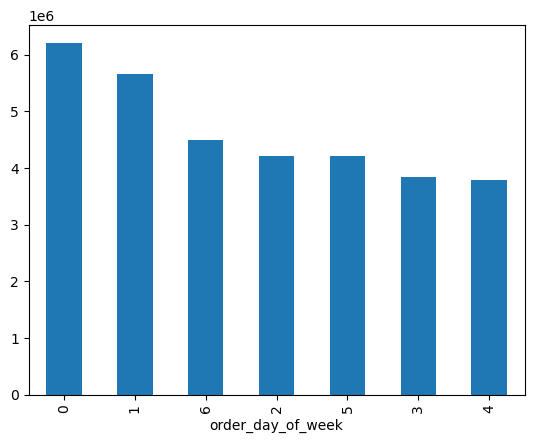

In [28]:
# Create the bar chart using the 'order_dow' column
df['order_day_of_week'].value_counts().plot.bar()


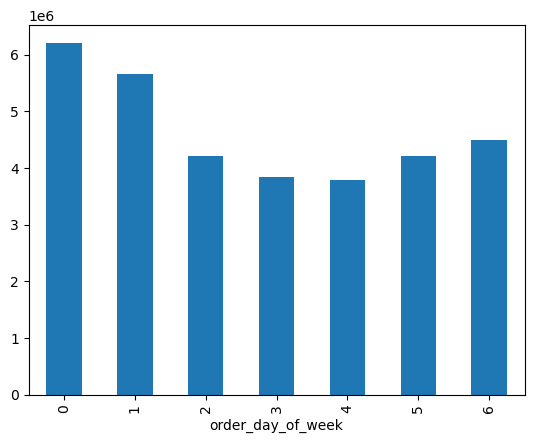

In [30]:
#indexing by order of days of week
bar = df['order_day_of_week'].value_counts().sort_index().plot.bar()

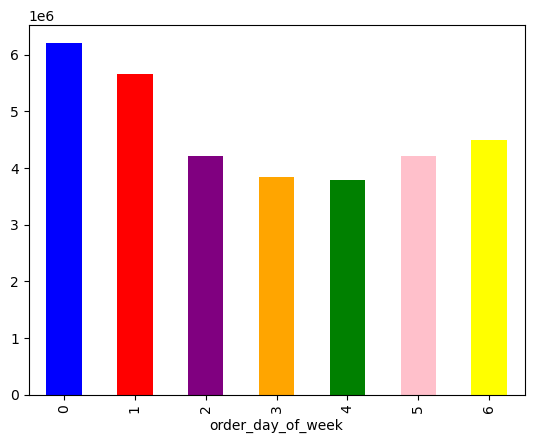

In [32]:
#adding colors
bar = df['order_day_of_week'].value_counts().sort_index().plot.bar(color =['blue','red','purple','orange','green','pink','yellow'])

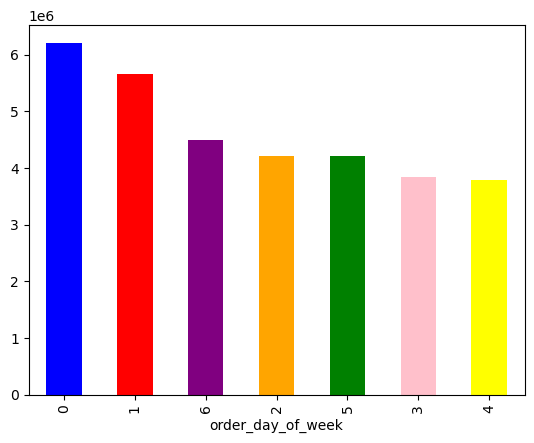

In [34]:
bar = df['order_day_of_week'].value_counts().plot.bar(color =['blue','red','purple','orange','green','pink','yellow'])

In [36]:
bar.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'bar_orders_dow.png'))

## Creating Histograms and Scatterplots

<Axes: ylabel='Frequency'>

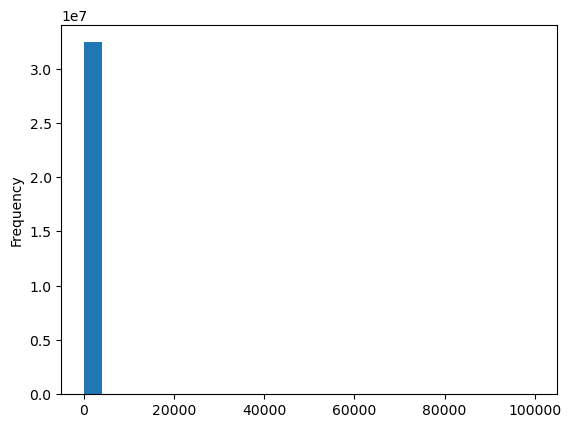

In [38]:
#creating histogram
df['prices'].plot.hist(bins = 25)

In [40]:
#describing 'prices'
df['prices'].describe()

count    3.243246e+07
mean     1.198149e+01
std      4.954445e+02
min      1.000000e+00
25%      4.200000e+00
50%      7.400000e+00
75%      1.130000e+01
max      9.999900e+04
Name: prices, dtype: float64

<Axes: xlabel='prices', ylabel='prices'>

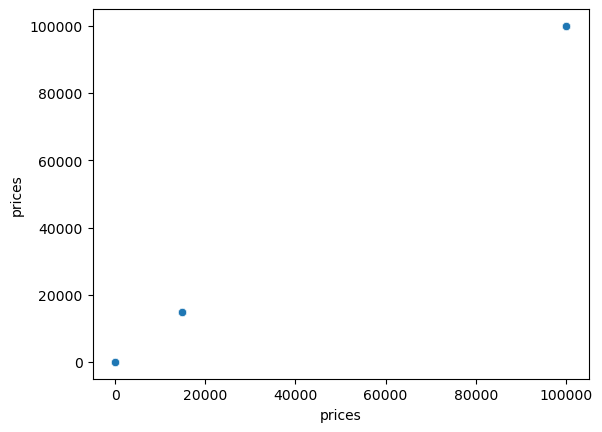

In [42]:
# ceating a scatterplot
sns.scatterplot(x = 'prices', y = 'prices',data = df)

In [43]:
#finding prices over $100
df.loc[df['prices'] > 100]

,order_id,user_id,order_number,order_day_of_week,order_hour_of_day,days_since_prior_order,product_id,add_to_cart_order,reordered,_merge,product_name,aisle_id,department_id,prices,price_range_loc,busiest_day,busiest_day_updated,slowest_day_updated,busiest_period_of_day
1576,912404,17,12,2,14,5.0,21553,5,0,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Regularly busy,Busiest days,Regularly busy,Average orders
1638,603376,17,22,6,16,4.0,21553,3,1,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Regularly busy,Busiest days,Regularly busy,Average orders
16532,3264360,135,2,2,21,13.0,21553,6,0,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Regularly busy,Busiest days,Regularly busy,Average orders
16538,892534,135,3,0,8,12.0,21553,3,1,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Busiest day,Busiest days,Slowest days,Average orders
53707,229704,342,8,1,19,30.0,21553,9,0,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Regularly busy,Busiest days,Regularly busy,Average orders
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32348036,3172853,205650,18,1,9,7.0,21553,17,1,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Regularly busy,Busiest days,Regularly busy,Average orders
32375268,2504315,205818,3,5,15,3.0,21553,13,0,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Regularly busy,Busiest days,Regularly busy,Average orders
32375278,1108388,205818,5,4,5,1.0,21553,5,1,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Least busy,Regularly busy,Slowest days,Average orders
32408108,1916142,206049,1,2,17,NaN,21553,2,0,both,Lowfat 2% Milkfat Cottage Cheese,108,16,14900.0,High-range product,Regularly busy,Busiest days,Regularly busy,Average orders


In [44]:
#assigning null values to outliers
df.loc[df['prices'] >100, 'prices'] = np.nan

In [45]:
df['prices'].max()

25.0

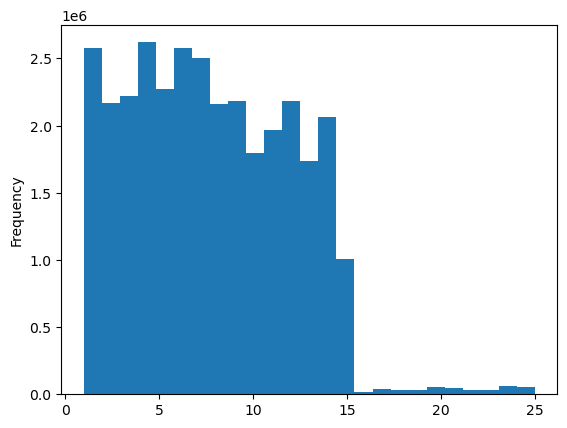

In [46]:
#creating histogram of prices
hist = df['prices'].plot.hist(bins = 25)

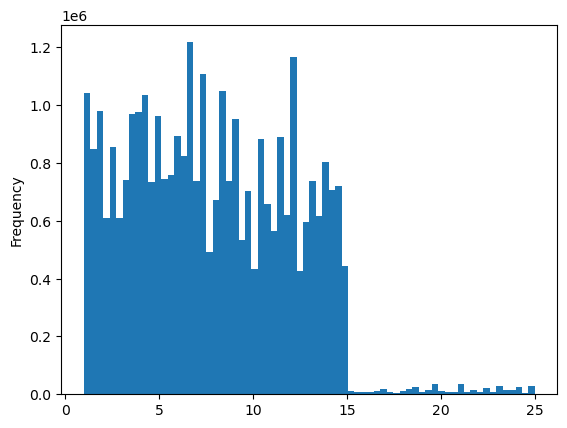

In [47]:
#more granularity
hist2 = df['prices'].plot.hist(bins = 70)

In [48]:
#exporting histogram and saving image
hist.figure.savefig(os.path.join(path, 'Analysis','Visualizations', 'hist_orders_prices.png'))

## Sampling Data

In [62]:
#set seed
np.random.seed(4)

In [60]:
#assigning 'dev'
dev = np.random.rand(len(df)) <= 0.7

In [64]:
#split into 'big' and 'small'
big = df[dev]
small = df[~dev]

In [66]:
#checking results
len(df)

32432460

In [68]:
len(big) + len(small)

32432460

In [72]:
# create dataframe using only the neccessary columns
df_2 = small[['order_day_of_week','prices']]

In [74]:
df_2.head()

,order_day_of_week,prices
0,2,9.0
2,2,4.4
3,2,4.7
6,3,3.0
10,3,4.0


## Creating a Line Chart

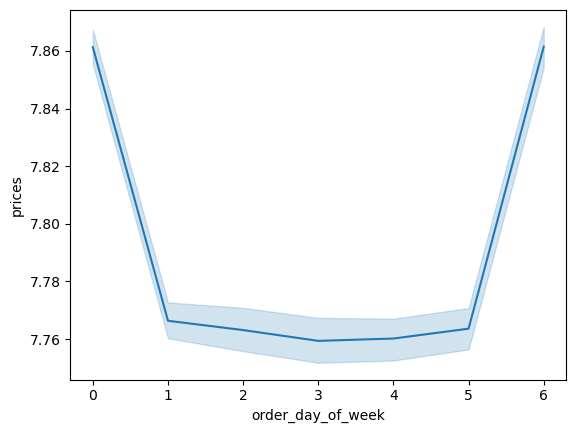

In [77]:
#creating a line chart
line = sns.lineplot(data = df_2, x = 'order_day_of_week',y = 'prices')

In [79]:
#creating smaller subset of main dataframe using only relevant columns
df_4 = df[['order_day_of_week', 'prices']]

In [86]:
# Verify if df_4 has the right columns and data
print(df_4.head())

   order_day_of_week  prices
0                  2     9.0
1                  2    12.5
2                  2     4.4
3                  2     4.7
4                  2     1.0


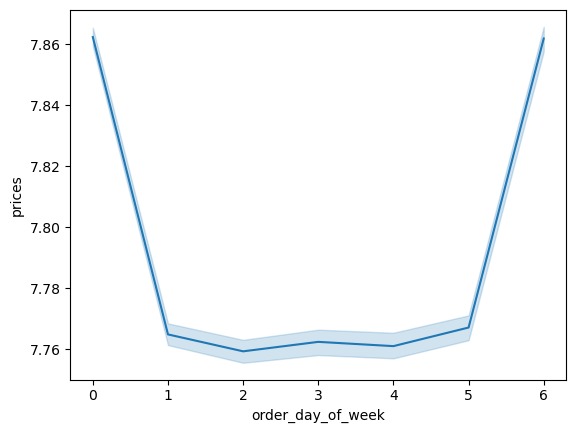

In [88]:
line_2 = sns.lineplot(data = df_4, x = 'order_day_of_week', y = 'prices')
